In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

In [ ]:
# 1 import database / data

In [2]:
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
# 2 Data Cleaning

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

In [6]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [7]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [8]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [9]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [10]:
# e. fix missing values - country

# df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [11]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [12]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [13]:
df_db_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [14]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [15]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [16]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [17]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [18]:
# drop columns
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [19]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
# 3 Feature Engineering and Data Analysis

In [20]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [21]:
df = (df_db_subscription.merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [22]:
df_db_subscription.shape

(21, 12)

In [23]:
df.shape

(23, 20)

In [24]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [25]:
df_db_subscription['customerid'].nunique()

21

In [26]:
df_db_customer['customerid'].nunique()

21

In [27]:
df_db_support['customerid'].nunique()

7

In [28]:
df_db_support['customerid'].size

9

In [29]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [30]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [31]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [32]:
df_db_support['customerid'].size

7

In [33]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [34]:
df.shape

(21, 21)

In [35]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [36]:
# Data Analysis

In [37]:
#1 Churn Rate

In [36]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [37]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [38]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [39]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [40]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [41]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1539 0


In [42]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [43]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [44]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.43


In [45]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [46]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [47]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [51]:
# 4 Visualization Using Matplotlib

In [48]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [49]:
df_visual.shape

(21, 23)

In [50]:
df_visual.columns


Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

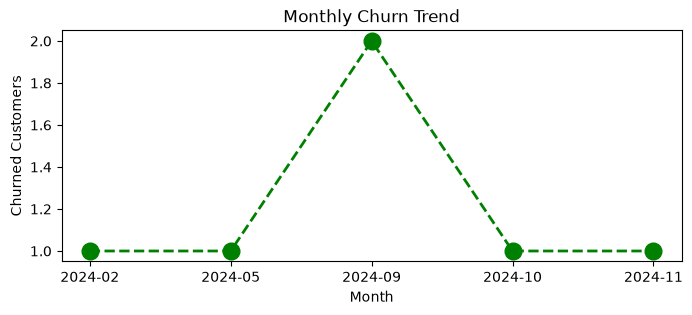

In [51]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

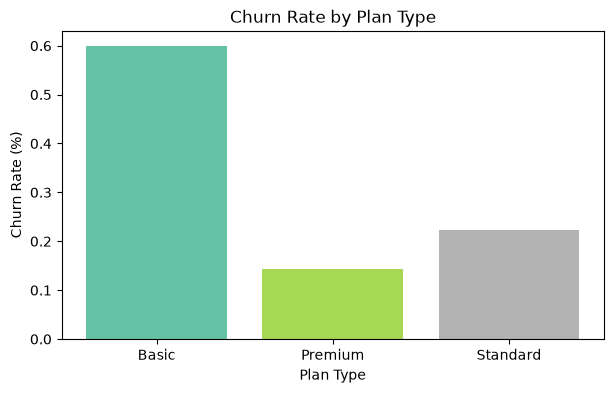

In [52]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

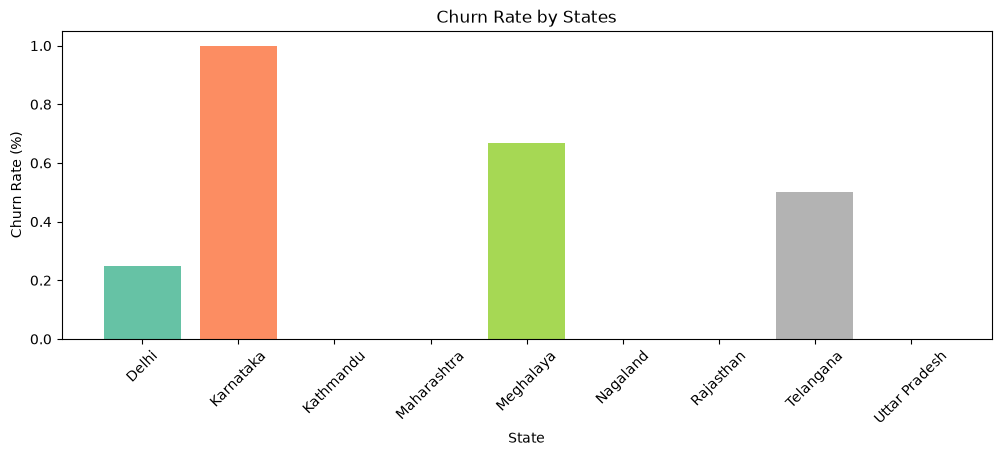

In [53]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by States')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Visualization Using Seaborn

In [54]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [55]:
# df_encoded =
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [56]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [57]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

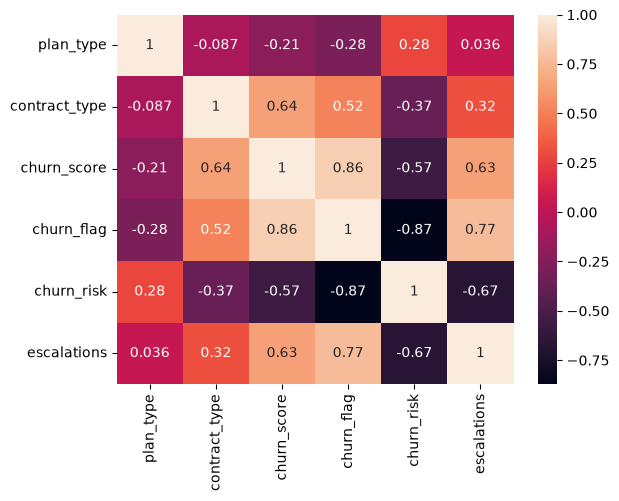

In [58]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [59]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [60]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [61]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [62]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

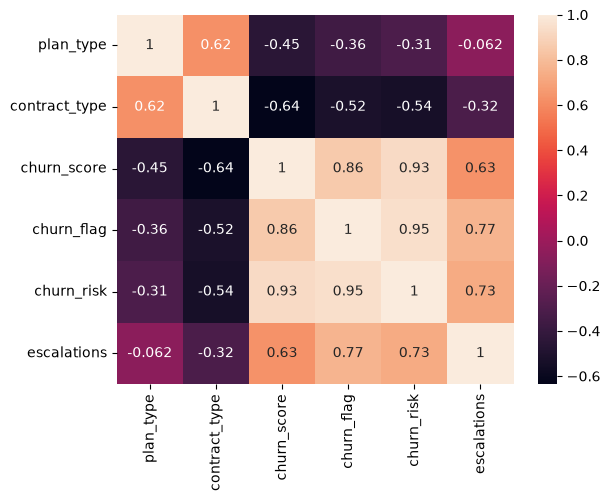

In [63]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

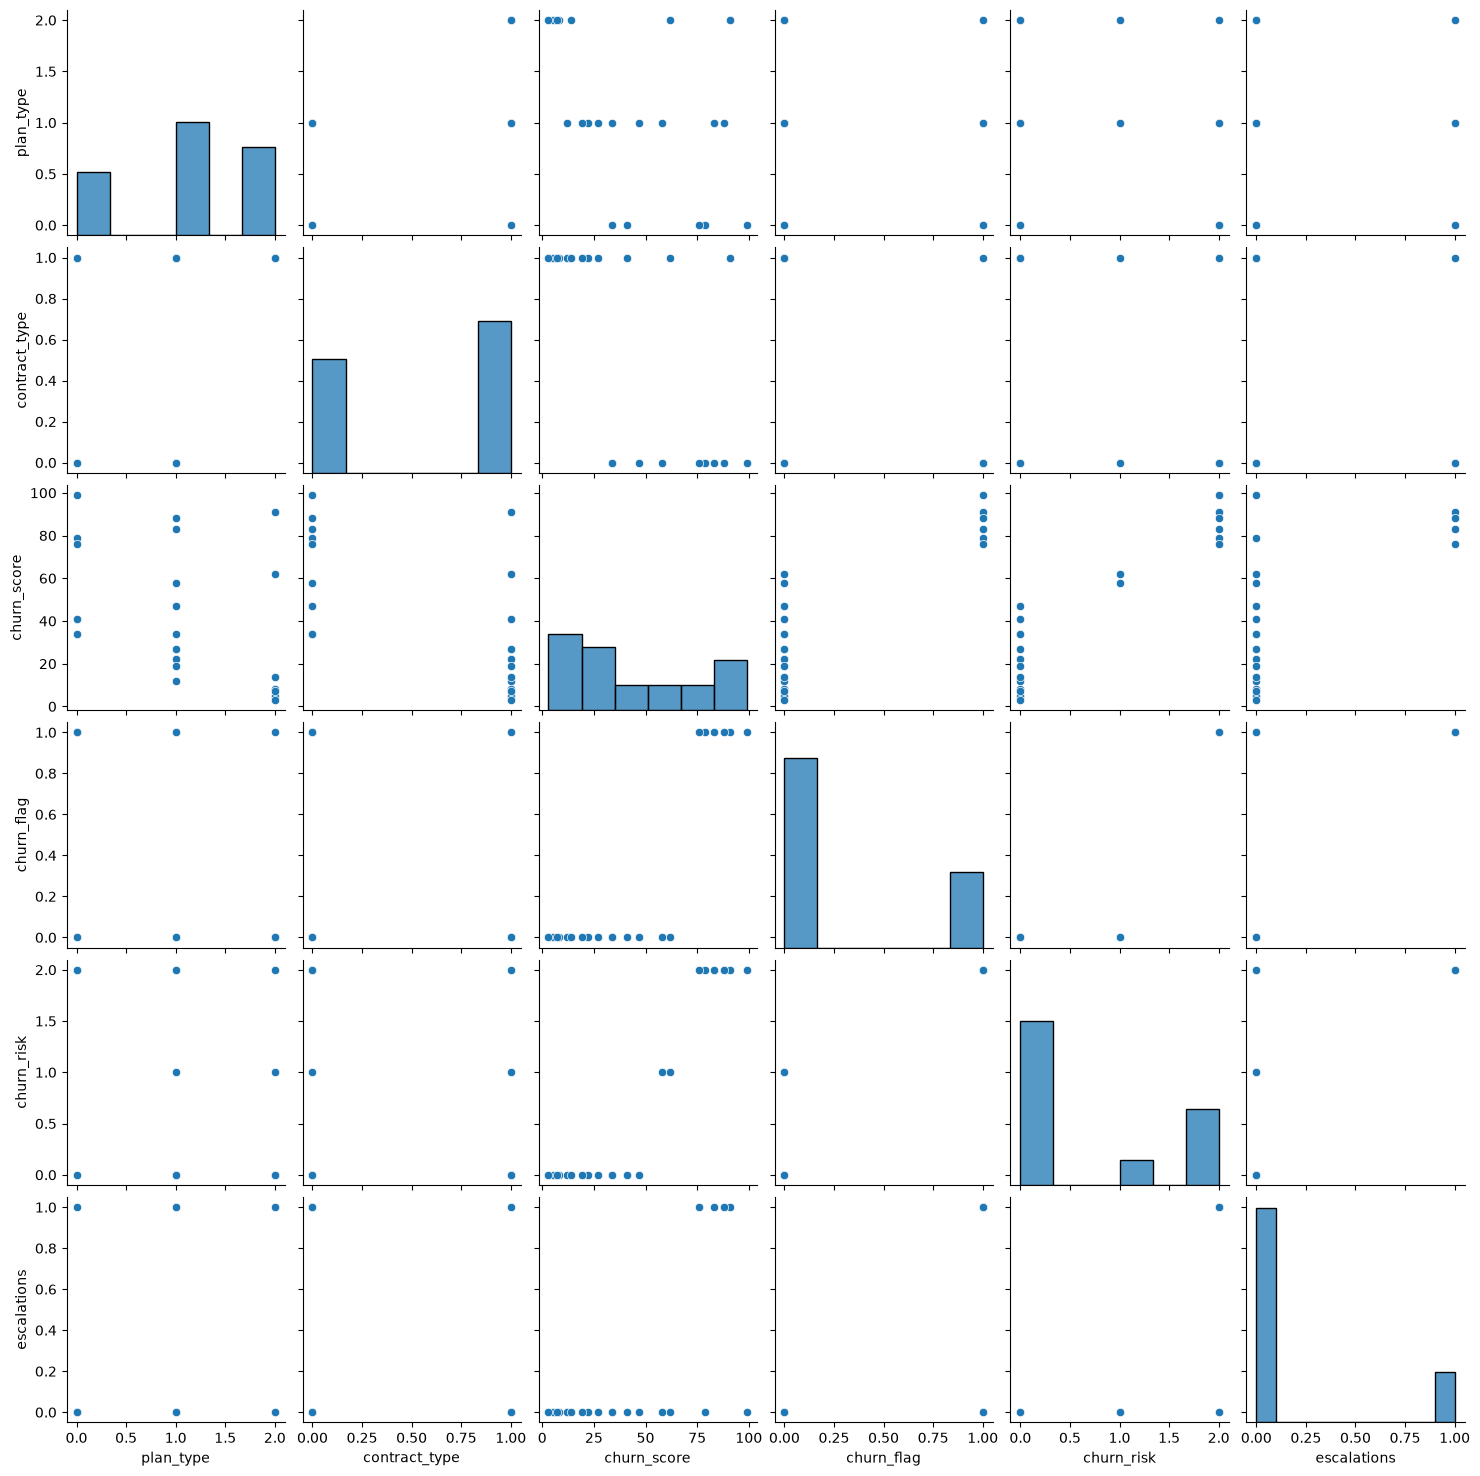

In [64]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

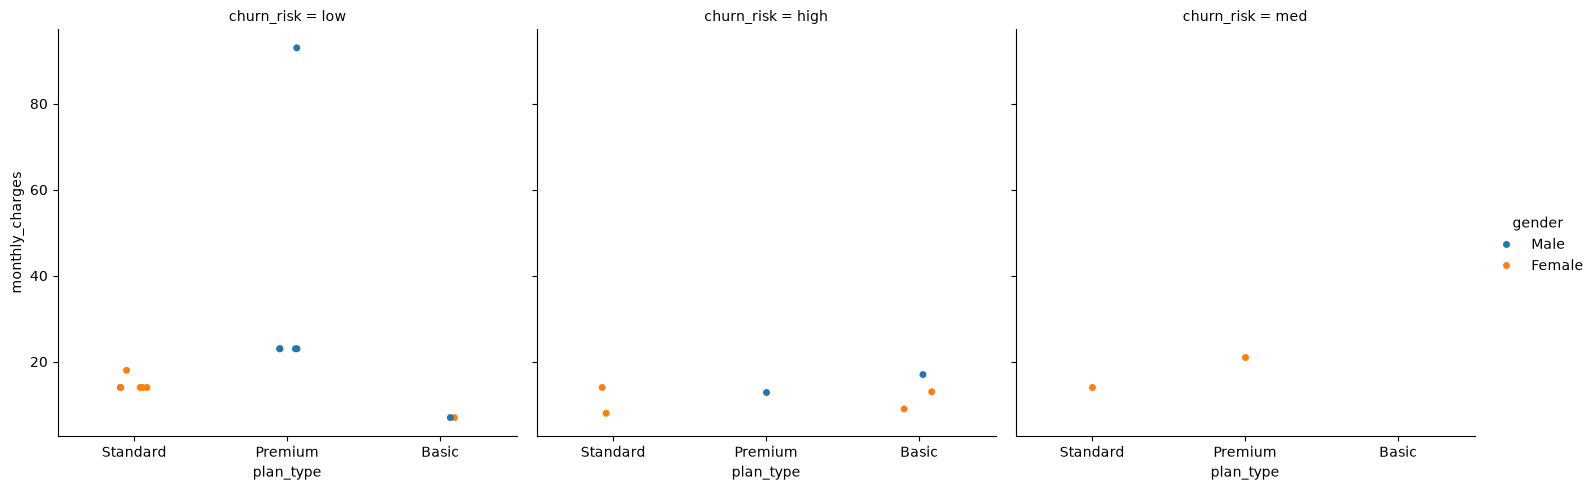

In [65]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [ ]:
# Pivot Table

In [66]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [67]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91
